## M5 Demand Forecasting - Basic EDA 

### Objective

The objective of this notebook is to peform initial exploration of the raw M5 dataset before data ingestion, wrangling and feature engineering.

The purpose of this basic eda is to understand:
- the structure and grain of each dataset
- the historical sales at item x store level
- the number of products, department, categories, stores and locations
- the product(item)/store hierarchy
- the calendar and price informartion of the products
- potential data quality and modelling considerations

The notebook focuses only on **initial data understanding**

Detailed data wrangling, time series analysis will be done after data ingestion and transformation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [2]:
sales = pd.read_csv("../data/raw/sales_train_validation.csv")
calendar = pd.read_csv("../data/raw/calendar.csv")
prices = pd.read_csv("../data/raw/sell_prices.csv")

In [3]:
print("Sales: ", sales.shape)
print("Calendar: ",calendar.shape)
print("Prices: ",prices.shape)

Sales:  (30490, 1919)
Calendar:  (1969, 14)
Prices:  (6841121, 4)


In [4]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 446.4 MB


In [5]:
sales.sample(10)

id          item_id      dept_id  \
3234     HOBBIES_1_191_CA_2_validation    HOBBIES_1_191    HOBBIES_1   
20354      FOODS_2_234_TX_3_validation      FOODS_2_234      FOODS_2   
5525       FOODS_3_252_CA_2_validation      FOODS_3_252      FOODS_3   
14082      FOODS_2_059_TX_1_validation      FOODS_2_059      FOODS_2   
7590   HOUSEHOLD_2_397_CA_3_validation  HOUSEHOLD_2_397  HOUSEHOLD_2   
30364      FOODS_3_700_WI_3_validation      FOODS_3_700      FOODS_3   
12641    HOBBIES_2_030_TX_1_validation    HOBBIES_2_030    HOBBIES_2   
2827       FOODS_3_603_CA_1_validation      FOODS_3_603      FOODS_3   
29791      FOODS_3_126_WI_3_validation      FOODS_3_126      FOODS_3   
26787      FOODS_3_171_WI_2_validation      FOODS_3_171      FOODS_3   

          cat_id store_id state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  \
3234     HOBBIES     CA_2       CA    0    0    0    0    0    0    0    0   
20354      FOODS     TX_3       TX    0    0    0    0    0    0    0    0   
5525       FOODS     CA_2       CA   33   28   17   15   11   19   24   40   
14082      FOODS     TX_1       TX    1    4    1    0    0    0    1    2   
7590   HOUSEHOLD     CA_3       CA    0    0    0    0    0    0    0    0   
30364      FOODS     WI_3       WI    0    1    1    0    2    1    2    3   
12641    HOBBIES     TX_1       TX    0    0    0    0    0    0    0    0   
2827       FOODS     CA_1       CA    0    0    0    0    0    0    0    0   
29791      FOODS     WI_3       WI    0    0    0    0    0    0    0    0   
26787      FOODS     WI_2       WI    0    0    0    0    0    0    0    0   

       d_9  d_10  d_11  d_12  d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  \
3234     0     0     0     0     0     0     0     0     0     0     0     0   
20354    0     0     0     0     0     0     0     0     0     0     0     0   
5525    15    12    19    26    17    36    62    39    11    11    18    13   
14082    2     1     1     1     2     2     4     5     0     3     1     1   
7590     0     0     0     0     0     0     0     0     0     0     0     0   
30364    5     0     1     0     0     0     5     3     0     2     4     0   
12641    0     0     0     0     0     0     0     0     0     0     0     0   
2827     0     0     0     0     0     0     0     0     0     0     0     0   
29791    0     0     0     0     0     0     0     0     0     0     0     0   
26787    0     0     0     0     0     0     0     0     0     0     0     0   

       d_21  d_22  d_23  d_24  d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  \
3234      0     0     0     0     0     0     0     0     0     0     0     0   
20354     0     0     0     0     0     0     0     0     0     0     0     0   
5525     19    33    37    30    15    13    13    15    44    24    18    33   
14082     3     0     4     1     5     1     0     0     1     3     1     2   
7590      0     0     0     0     0     0     0     0     0     0     0     0   
30364     2     5     1     2     0     3     2     3     5     3     3     2   
12641     0     0     0     0     0     0     0     0     0     0     0     0   
2827      0     0     0     0     0     0     0     0     0     0     0     0   
29791     0     0     0     0     0     0     0     0     0     0     0     0   
26787     0     0     0     0     0     0     0     0     0     0     0     0   

       d_33  d_34  d_35  d_36  d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  \
3234      0     0     0     0     0     0     0     0     0     0     0     0   
20354     0     0     0     0     0     0     0     0     0     0     0     0   
5525     21    19    28    54    30    10    17    22    16    31    42    41   
14082     2     2     1     3     4     1     0     0     0     0     0     5   
7590      0     0     0     0     0     0     0     0     0     0     0     0   
30364     3     0     3     0     0     0     0     2     2     3     1     0   
12641     0     0     0     0     0     0   

In [6]:
daily_sales_columns = [col for col in sales.columns if col.startswith("d_")]

print(f"Number of daily sales columns: {len(daily_sales_columns)}")

Number of daily sales columns: 1913


### Observation

- The sales dataset contains daily sales at item x store level in wider format.

- The first 6 columns contains details about product, department, store, location and category while `d_1` to `d_1913` columns contain daily sales.
- Here each `d_*` column represents one day in the historical period and it is the identifier rather than actual date. 
- The corresponding dates are present in calendar dataset.


In [7]:
print("Unique ID: ",sales["id"].nunique())
print("Unique items: ",sales["item_id"].nunique())
print("Unique stores: ",sales["store_id"].nunique())
print("Unique departments: ",sales["dept_id"].nunique())
print("Unique categories: ",sales["cat_id"].nunique())
print("Unique states: ",sales["state_id"].nunique())

Unique ID:  30490
Unique items:  3049
Unique stores:  10
Unique departments:  7
Unique categories:  3
Unique states:  3


In [8]:
sales[["item_id","store_id"]].shape

(30490, 2)

In [9]:
sales.groupby("id")[["item_id", "store_id"]].nunique().max()

item_id     1
store_id    1
dtype: int64

In [10]:
check = sales.groupby("id")[["item_id", "store_id"]].nunique()
check[(check["item_id"]>1)|(check["store_id"]>1)] # there is unique combination of item_id x store_id (grain of the data)

,item_id,store_id
id,,


### Observation

- The grain of the dataset is **item x store**
- For example:
    - item_1 + CA_1 -> d_1,d_2.....d_1913
    - item_2 + CA_1 -> d_1,d_2.....d_1913
- Each item and store combination has daily sales data across the historical period.
- Therefore, the problem consist of forecasting multiple parallel item-store level time series rather than at store level.

In [11]:
sales["state_id"].value_counts()

state_id
CA    12196
TX     9147
WI     9147
Name: count, dtype: int64

In [12]:
sales["store_id"].value_counts()

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64

In [13]:
sales["cat_id"].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

In [14]:
sales["dept_id"].value_counts()

dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: int64

In [15]:
sales[["state_id","store_id","cat_id","dept_id","item_id"]].drop_duplicates().head()

,state_id,store_id,cat_id,dept_id,item_id
0,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_001
1,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_002
2,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_003
3,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_004
4,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_005


In [16]:
sales[["state_id","store_id","cat_id","dept_id"]].value_counts()

state_id  store_id  cat_id     dept_id    
CA        CA_1      FOODS      FOODS_3        823
          CA_2      FOODS      FOODS_3        823
          CA_3      FOODS      FOODS_3        823
          CA_4      FOODS      FOODS_3        823
TX        TX_1      FOODS      FOODS_3        823
          TX_2      FOODS      FOODS_3        823
          TX_3      FOODS      FOODS_3        823
WI        WI_1      FOODS      FOODS_3        823
          WI_2      FOODS      FOODS_3        823
          WI_3      FOODS      FOODS_3        823
CA        CA_1      HOUSEHOLD  HOUSEHOLD_1    532
          CA_2      HOUSEHOLD  HOUSEHOLD_1    532
          CA_3      HOUSEHOLD  HOUSEHOLD_1    532
          CA_4      HOUSEHOLD  HOUSEHOLD_1    532
TX        TX_1      HOUSEHOLD  HOUSEHOLD_1    532
          TX_2      HOUSEHOLD  HOUSEHOLD_1    532
          TX_3      HOUSEHOLD  HOUSEHOLD_1    532
WI        WI_1      HOUSEHOLD  HOUSEHOLD_1    532
          WI_2      HOUSEHOLD  HOUSEHOLD_1    532
       

### Observation — Product and store hierarchy

The sales data contains multiple levels of business hierarchy:

**State → Store → Category → Department → Item**

The demand is recorded at the lowest operational level relevant to our
forecasting problem: **item × store**.

The hierarchy allows the same demand data to be analysed or aggregated at
different levels, such as:

- individual item
- department
- category
- store
- state



In [39]:
calendar.head(10)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


In [18]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [19]:
calendar["date"]= pd.to_datetime(calendar["date"])

In [20]:
calendar[["d","date"]].head()

,d,date
0,d_1,2011-01-29
1,d_2,2011-01-30
2,d_3,2011-01-31
3,d_4,2011-02-01
4,d_5,2011-02-02


In [21]:
# to verify whether day identifiers exist in calendar
set(daily_sales_columns).issubset(set(calendar["d"]))


True

In [22]:
print("Calendar start date", calendar["date"].min())
print("Calendar end date", calendar["date"].max())
print("Number of calendar days", calendar["date"].nunique())

Calendar start date 2011-01-29 00:00:00
Calendar end date 2016-06-19 00:00:00
Number of calendar days 1969


In [23]:
calendar[["d","date"]]

,d,date
0,d_1,2011-01-29
1,d_2,2011-01-30
2,d_3,2011-01-31
3,d_4,2011-02-01
4,d_5,2011-02-02
...,...,...
1964,d_1965,2016-06-15
1965,d_1966,2016-06-16
1966,d_1967,2016-06-17
1967,d_1968,2016-06-18


### Observations

- Calendar dataset provides the mapping for `d_*` sales identifiers with the actual dates.
- The historical sales data represents continous daily observations across multiple years (from 2011 to 2016)
- The sales history spans from **2011-01-29** and **2016-06-19**

In [24]:
day_to_date = calendar.set_index("d")["date"]
day_to_date

d
d_1      2011-01-29
d_2      2011-01-30
d_3      2011-01-31
d_4      2011-02-01
d_5      2011-02-02
            ...    
d_1965   2016-06-15
d_1966   2016-06-16
d_1967   2016-06-17
d_1968   2016-06-18
d_1969   2016-06-19
Name: date, Length: 1969, dtype: datetime64[us]

In [25]:
day_to_date.loc[daily_sales_columns].sort_values().diff().max() # the dates are consecutive, hence no gap

Timedelta('1 days 00:00:00')

In [26]:
sales.isna().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 1919, dtype: int64

In [27]:
missing_sales = (sales[daily_sales_columns] == 0).sum().sum()
print(f"Missing daily sales observations: {missing_sales}")

total_obervations = sales[daily_sales_columns].size
missing_pct = (missing_sales / total_obervations) * 100

print(f"Missing sales percentage: {missing_pct:.4f}%")

Missing daily sales observations: 39777094
Missing sales percentage: 68.1963%


In [28]:
print("Duplicate Ids:", sales["id"].duplicated().sum())

Duplicate Ids: 0


In [29]:
print("Duplicate item-store combinations:", sales[["item_id","store_id"]].duplicated().sum())

Duplicate item-store combinations: 0


In [30]:
negative_sales = (sales[daily_sales_columns]<0).sum().sum()
print(f"Negative sales observations: {negative_sales}")

Negative sales observations: 0


### Observations

Basic data quality checks performed on sales dataset before transformation.

- missing identifier
- missing daily sales (in percentage)
- duplicate item-store combibnations
- negative sales values

These checks are performed to identify issues that needs to be addressed during ingestion/wrangling

In [31]:
print("Minimum sales: ",sales[daily_sales_columns].min().min())
print("Maximum sales: ",sales[daily_sales_columns].max().max())
print("Mean sales: ",sales[daily_sales_columns].mean().mean())
print("Median sales: ",sales[daily_sales_columns].stack().median())

Minimum sales:  0
Maximum sales:  763
Mean sales:  1.126322153733316
Median sales:  0.0


### Observations

- Daily sales vary substantially across item-store combinatons.
- The mean and median should be compared because a large difference between the 
  two indicates right skewed distribution, where a relatively small number of high-volume observations contribute
  disproportionately to total sales.
- From the dataset we have observed that **mean is 1.126** and **median is 0**, which indicates that roughly **50%** of the daily item-store
  sales observations are 0 (no sales) while relatively small number of observations generate positive sales and sometimes substantially 
  higher sales volumes, pulling the mean upward.

In [32]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [33]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB


In [35]:
print("Total rows:",len(prices))
print("Unique stores:",prices["store_id"].nunique())
print("Unique items:",prices["item_id"].nunique())
print("Unique weeks:",prices["wm_yr_wk"].nunique())

Total rows: 6841121
Unique stores: 10
Unique items: 3049
Unique weeks: 282


In [36]:
prices["sell_price"].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

In [37]:
# missing prices
prices["sell_price"].isna().sum()

np.int64(0)

In [38]:
# grain is at item + store + wm_yr_wk
prices[["store_id","item_id","wm_yr_wk"]].duplicated().sum() # no duplicates at grain level

np.int64(0)

### Observations

- The grain of the price dataset is **item - store - week**
- Selling price is available at a weekly rather than daily frequency
- `wm_yr_wk` field is related to corresponding week in calendar dataset which means it needs to be connected with
  daily sales observations in sales dataset during data wrangling.

In [42]:
calendar["event_type_1"].value_counts()

event_type_1
Religious    55
National     52
Cultural     37
Sporting     18
Name: count, dtype: int64

In [44]:
calendar["event_name_1"].value_counts()

event_name_2
Father's day      2
Easter            1
Cinco De Mayo     1
OrthodoxEaster    1
Name: count, dtype: int64

In [45]:
calendar["event_name_2"].value_counts()

event_name_2
Father's day      2
Easter            1
Cinco De Mayo     1
OrthodoxEaster    1
Name: count, dtype: int64

In [47]:
calendar[["snap_CA","snap_TX","snap_WI"]].sum()

snap_CA    650
snap_TX    650
snap_WI    650
dtype: int64

In [57]:
daily_sales = sales[daily_sales_columns].sum(axis=0)
daily_sales.index = daily_sales.index.map(day_to_date)
daily_sales = daily_sales.sort_index()

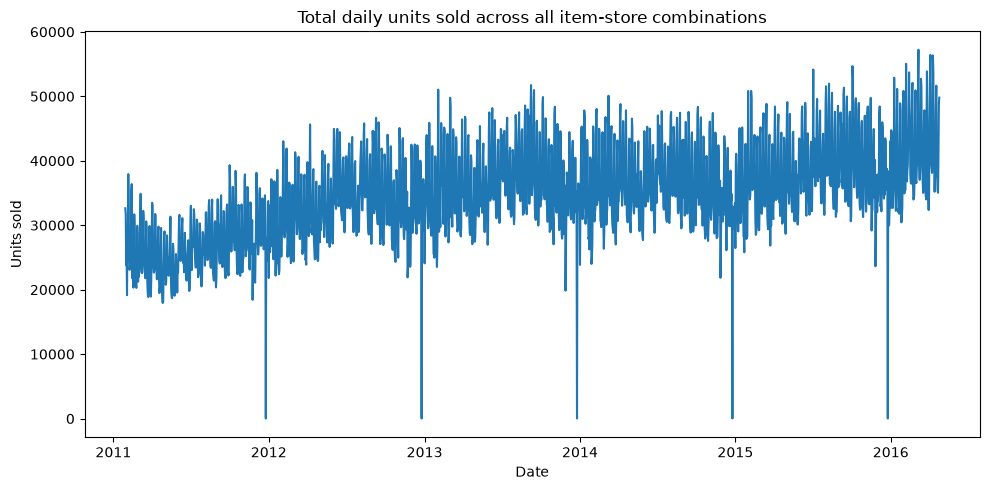

In [58]:
plt.figure(figsize=(10,5))
plt.plot(daily_sales.index,daily_sales.values)
plt.title("Total daily units sold across all item-store combinations")
plt.xlabel("Date")
plt.ylabel("Units sold")

plt.tight_layout()
plt.show()

### Data Discovery Conclusion

#### 1. Sales dataset

- Sales dataset contains historical daily observations
- Data is in wider format
- Each value represents units sold
- The grain of the dataset is item x store
- Each row represents daily demand time series at item x store level
  
#### 2. Calendar dataset

- mapping from `d_*` identifiers to dates
- weekday
- month
- year
- week identifiers
- events
- SNAP information

Calendar dataset provides temporal and explanatory information for the demand series.


#### 3. Price dataset

- sell_price dataset contains weekly selling prices for item x store combinations
- Weekly sales prices can be later associuated with daily sales using the calendar/week information
  

#### 4. Business Hierarchy

**State -> Store -> Category -> Department -> Item**

Lowest level of demand forecasting is

**Item x Store x Day**